<a href="https://colab.research.google.com/github/Gan4x4/cv/blob/main/Convolutional_neural_network/Gradient_ascent_GradCAM.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


#### Анализ ResNet18

In [ ]:
!wget -nc 'https://ml.gan4x4.ru/msu/dep-1.9/L10/cat_and_dog1.jpg' -O cat_and_dog1.jpg
!wget -nc 'https://ml.gan4x4.ru/msu/dep-1.9/L10/cat_and_dog2.png' -O cat_and_dog2.png
!wget -nc 'https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json' -O imagenet_class_index.json

--2023-11-22 16:34:56--  https://ml.gan4x4.ru/msu/dep-1.9/L10/cat_and_dog1.jpg
Resolving ml.gan4x4.ru (ml.gan4x4.ru)... 212.24.105.216
Connecting to ml.gan4x4.ru (ml.gan4x4.ru)|212.24.105.216|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51452 (50K) [image/jpeg]
Saving to: ‘cat_and_dog1.jpg’

cat_and_dog1.jpg    100%[===================>]  50.25K   149KB/s    in 0.3s    

2023-11-22 16:34:58 (149 KB/s) - ‘cat_and_dog1.jpg’ saved [51452/51452]

--2023-11-22 16:34:58--  https://ml.gan4x4.ru/msu/dep-1.9/L10/cat_and_dog2.png
Resolving ml.gan4x4.ru (ml.gan4x4.ru)... 212.24.105.216
Connecting to ml.gan4x4.ru (ml.gan4x4.ru)|212.24.105.216|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 376776 (368K) [image/png]
Saving to: ‘cat_and_dog2.png’

cat_and_dog2.png    100%[===================>] 367.95K   243KB/s    in 1.5s    

2023-11-22 16:35:00 (243 KB/s) - ‘cat_and_dog2.png’ saved [376776/376776]

--2023-11-22 16:35:00--  https://s3.amazonaws

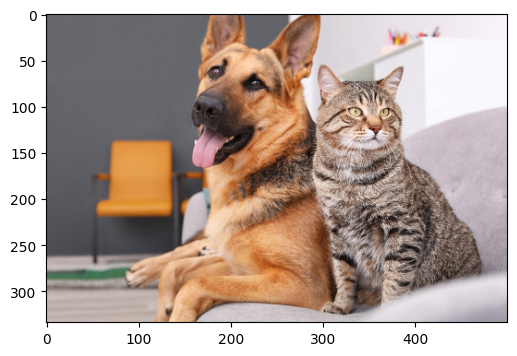

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

plt.figure(figsize = (6,4))

def get_image(path):
    with open(os.path.abspath(path), 'rb') as f:
        with Image.open(f) as img:
            return img.convert('RGB')

img = get_image('cat_and_dog1.jpg')
plt.imshow(img)
plt.show()

Теперь нам нужно преобразовать это изображение в тензор Pytorch, а также его нормализовать для использования в нашей предварительно обученной модели.

In [ ]:
from torchvision import transforms

# resize & normalize
def get_input_transform():
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225])
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop((224, 224)),
        transforms.ToTensor(),
        normalize])
    return transform

def get_input_tensors(img):
    transform = get_input_transform()
    # unsqeeze converts single image to batch of 1
    return transform(img).unsqueeze(0)


Загрузим предобученную модель Resnet18, доступную в Pytorch и классы изображений из ImageNet.

In [ ]:
from torchvision import models
import json

model = models.resnet18(pretrained=True)

idx2label, cls2label, cls2idx = [], {}, {}
with open(os.path.abspath('/content/imagenet_class_index.json'), 'r') as read_file:
    class_idx = json.load(read_file)
    idx2label = [class_idx[str(k)][1] for k in range(len(class_idx))]
    cls2label = {class_idx[str(k)][0]: class_idx[str(k)][1] for k in range(len(class_idx))}
    cls2idx = {class_idx[str(k)][0]: k for k in range(len(class_idx))}

Получим предсказание. А после этого полученные нами прогнозы (логиты), пропустим это через softmax, чтобы получить вероятности и метки классов для 5 лучших прогнозов.

((0.22211862, 281, 'tabby'),
 (0.17559119, 282, 'tiger_cat'),
 (0.12574267, 235, 'German_shepherd'),
 (0.06012665, 285, 'Egyptian_cat'),
 (0.015657645, 811, 'space_heater'))

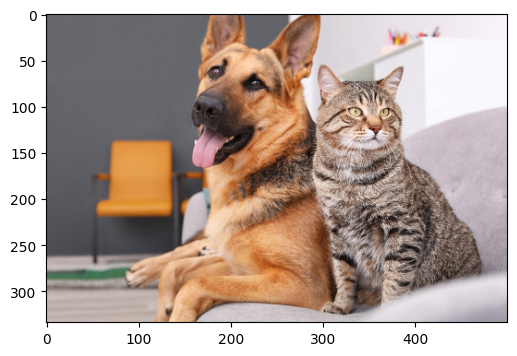

In [ ]:
import torch.nn.functional as F

plt.figure(figsize = (6,4))

img_t = get_input_tensors(img)
model.eval()
logits = model(img_t)

probs = F.softmax(logits, dim=1)
probs5 = probs.topk(5)
plt.imshow(img)
tuple((p,c, idx2label[c]) for p, c in zip(probs5[0][0].detach().numpy(), probs5[1][0].detach().numpy()))

(tabby - это тоже кошка.)

### Gradient Ascent

Имея информацию о структуре модели, можно использовать градиент, чтобы понять, как входы связаны с выходом.


Вместо того чтобы случайным образом закрашивать части изображения и много раз запускать модель, мы можем один раз посчитать градиент по входному изображению, и понять какие пикселы оказали наибольшее влияние на предсказание модели.

<img src ="https://ml.gan4x4.ru/msu/dep-1.9/L10/saliency_via_backprop.png" width="800">

Воспользуемся изображением из предыдущего примера

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
img_t.requires_grad = True # Tell pytorch to compute grads w.r.t. inputs too
logits = model(img_t.to(device)) # [1,1000] batch of one element, 1000 class scores
top_score, top_idx = logits[0].topk(1) # Get id of class with best score
id = top_idx[0].item()
print(id, idx2label[id]) # Print the label this class
score = logits[0][id] # Model output for paticular class

281 tabby


Для выхода модели соответствующему нашему классу рассчитываем градиент.

In [ ]:
# Compute gradients

score.backward(retain_graph=True)

# retain_grad = True is not nessesary
# But if we run this code second time, we got a torch error without it
# because pytorch want to accumulate gradients explicitly

print(img_t.grad.shape)
print(img_t.grad[0,:3,:3]) # Show some parts d_Image/d_score

torch.Size([1, 3, 224, 224])
tensor([[[ 5.1147e-03,  5.0598e-03,  1.7169e-03,  ..., -1.6558e-03,
           1.6304e-03, -3.7873e-03],
         [ 5.7010e-03,  3.6503e-03,  7.1631e-04,  ..., -6.1748e-03,
          -2.2976e-03,  1.3499e-03],
         [ 3.7273e-03,  2.7580e-03, -2.0229e-03,  ..., -2.6839e-03,
          -3.7937e-04, -6.4949e-05]],

        [[ 1.1459e-04, -3.0109e-03, -8.9941e-03,  ..., -2.3368e-03,
           2.3905e-03, -4.1957e-03],
         [-2.9808e-04, -7.2943e-03, -1.4450e-02,  ..., -1.0359e-02,
          -5.6886e-03,  3.1071e-04],
         [-2.6096e-03, -8.3244e-03, -1.8948e-02,  ..., -1.1152e-02,
          -7.3259e-03, -4.2692e-03]],

        [[-1.2640e-03, -2.5732e-03, -4.9612e-03,  ...,  5.8935e-04,
           3.9870e-03, -3.0836e-03],
         [-1.6096e-03, -5.0450e-03, -7.3928e-03,  ..., -3.2213e-03,
          -1.0713e-03,  1.0779e-03],
         [-1.7636e-03, -4.3827e-03, -8.7855e-03,  ..., -1.7277e-03,
          -2.1604e-03, -2.6171e-03]]])


У входного тензора (изображения) появился градиент, который указывает на то, как каждый элемент повлиял на выход модели. Отобразим этот градиент.

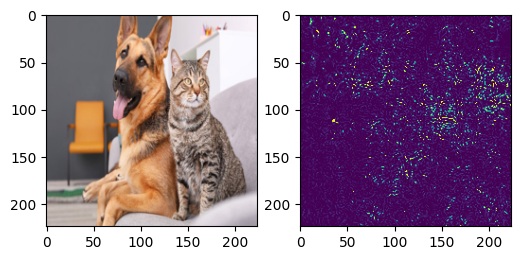

In [ ]:
import numpy as np

plt.figure(figsize = (6,4))

# Helper method to display grad
def grad_to_image(raw_grads):
    grad_of_first_batch_element = raw_grads[0]
    # Summ grads of RGB channes
    smap = torch.sum(grad_of_first_batch_element, dim=0)
    # Translate raw grad values to byte [0 .. 255] for displaying
    max_val = smap.max()
    img = (smap / max_val) * 255
    # Filter using threshold to make image sharp
    img[img < 0] = 0
    img[img > 50] = 255
    return img.numpy().astype(int)

sailency_map = grad_to_image(img_t.grad)

plt.subplot(1, 2, 1)
plt.imshow(np.array(img.resize((224,224))))
plt.subplot(1, 2, 2)
plt.imshow(sailency_map)
plt.show()

#### Adversarial attacks

Принцип взятия градиента по входу используется при состязательных атаках (adversarial attacks).

Если не просто визуализировать градиент, а с его помощью менять изображение, то можно обмануть сеть и заставить ее неверно классифицировать картинку незначительно поменяв ее.

<img src ="https://ml.gan4x4.ru/msu/dep-1.9/L10/adversarial_attack.jpg" width="700">




Подробнее:
[[wiki] Adversarial machine learning](https://en.wikipedia.org/wiki/Adversarial_machine_learning)

[The Intuition behind Adversarial Attacks on Neural Networks](https://blog.mlreview.com/the-intuition-behind-adversarial-attacks-on-neural-networks-71fdd427a33b)


Пиксели, получившие большой градиент, находится именно в том месте, где изображена собака - это хорошо.

При этом есть группы пикселей вверху изображения, которые тоже подсвечены, но относятся к фону - это плохо. Значит, модель может ошибаться из-за такого рода фона.


На этом принципе построен модуль [shap.DeepExplainer](https://shap-lrjball.readthedocs.io/en/latest/generated/shap.DeepExplainer.html).

Он уже не зависим от модели(not Model agnostic) так как использует градиенты, зато позволяет оценить связи более точно.


In [ ]:
!pip install grad-cam

In [ ]:
from torchvision.models import resnet18
import torchvision

model = resnet18(weights = torchvision.models.ResNet18_Weights)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
!wget -nc https://ml.gan4x4.ru/msu/dep-1.9/L10/cat_and_dog1.jpg

File ‘cat_and_dog1.jpg’ already there; not retrieving.



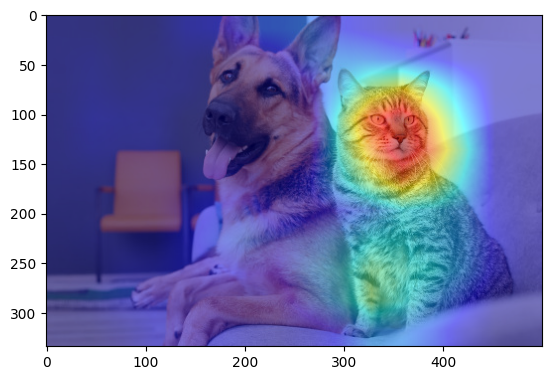

In [ ]:
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

pil = Image.open('cat_and_dog1.jpg')

input_tensor = pil_to_tensor(pil).float() / 255# Create an input tensor image for your model..
# Note: input_tensor can be a batch tensor with several images!


target_layers = [model.layer4[-1]]
# Construct the CAM object once, and then re-use it on many images:
cam = GradCAM(model=model, target_layers=target_layers, use_cuda=False)
targets = [ClassifierOutputTarget(281)]

#print(input_tensor)
grayscale_cam = cam(input_tensor=input_tensor.unsqueeze(0), targets=targets)

# In this example grayscale_cam has only one image in the batch:
grayscale_cam = grayscale_cam[0, :]
#img = Image.open('image.png').convert('L')
rgb_image = np.array(pil).astype(float)/255
visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)


#print(visualization)
plt.imshow(visualization)
plt.show()



